# The Product Pricer Continued

A model that can estimate how much something costs, from its description.

## Baseline Models

Today we work on the simplest models to act as a starting point that we will beat.

In [1]:
# imports

import os
import math
import json
import random
from dotenv import load_dotenv
from huggingface_hub import login
import matplotlib.pyplot as plt
import numpy as np
import pickle
from collections import Counter

In [2]:
# More imports for our traditional machine learning

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

## NLP imports

In the next cell, we have more imports for our NLP related machine learning.  
If the gensim import gives you an error like "Cannot import name 'triu' from 'scipy.linalg' then please run in another cell:  
`!pip install "scipy<1.13"`  
As described on StackOverflow [here](https://stackoverflow.com/questions/78279136/importerror-cannot-import-name-triu-from-scipy-linalg-when-importing-gens).  
Many thanks to students Arnaldo G and Ard V for sorting this.

In [3]:
# NLP related imports

from sklearn.feature_extraction.text import CountVectorizer
from gensim.models import Word2Vec
from gensim.utils import simple_preprocess

In [4]:
# Finally, more imports for more advanced machine learning

from sklearn.svm import LinearSVR
from sklearn.ensemble import RandomForestRegressor

In [5]:
# Constants - used for printing to stdout in color

GREEN = "\033[92m"
YELLOW = "\033[93m"
RED = "\033[91m"
RESET = "\033[0m"
COLOR_MAP = {"red":RED, "orange": YELLOW, "green": GREEN}

In [6]:
# environment

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['ANTHROPIC_API_KEY'] = os.getenv('ANTHROPIC_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HUGGING_FACE_TOKEN', 'your-key-if-not-using-env')

In [7]:
# Log in to HuggingFace

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [8]:
# One more import after logging in

from items import Item

In [9]:
%matplotlib inline

# Loading the pkl files

Let's avoid curating all our data again! Load in the pickle files

If you didn't already create these in Day 2, you can also download them from my google drive (you'll also find the slides here):  
https://drive.google.com/drive/folders/1JwNorpRHdnf_pU0GE5yYtfKlyrKC3CoV?usp=sharing

But note that the files are quite large - you might need to get a coffee!

In [10]:
with open('train.pkl', 'rb') as file:
    train = pickle.load(file)

with open('test.pkl', 'rb') as file:
    test = pickle.load(file)

In [11]:
# Remind ourselves the training prompt

print(train[1].prompt)

How much does this cost to the nearest dollar?

S.H.Figuarts First order Storm Trooper (shield and baton set)
S.H.Figuarts First order Storm Trooper (shield and baton set) Main body Replacement wrist 2 each Beta plast Riot shield (complete set) Z6 Riot Control Button (complete set) Star Wars / First Order Stormtrooper that appeared in the awakening of Force commercialized with soul web shop limited equipment. Z6 Riot control baton can reproduce two forms recombination. It is a premium Bandai limited item. It is cool! Dimensions 7.01 x 1.81 x 5.91 inches, Weight 5.1 ounces, model number Manufacturer recommended age 12 years and up, Rank Toys & Games Action Figures 64352,

Price is $85.00


In [12]:
# Remind a test prompt

print(train[1].price)

84.75


In [13]:
print(test[1].test_prompt())

How much does this cost to the nearest dollar?

Dreamus LIGHTSUM - Into The Light 1st Mini Album+Folded Poster (Random ver.), 150 x 175 x 32 mm
🎈KPOP MARKET (HANTEO & GAON Chart Family Shop) will ship your order from South Korea. 📆Release Date 🎵CD + 84p Booklet + Lyric Paper + Photocard (Random 1 out of 8) + Scratch Card (Random 1 out of 8) + Mini Poster (Random 1 out of 8) + ID Card (Pre-Order Only) 📌100% Original Brand New Item. Sales volume is reflected in the HANTEO and GAON Charts. 🎁 Safe packaging with traceable delivery

Price is $


## Unveiling a mighty script that we will use a lot!

A rather pleasing Test Harness that will evaluate any model against 250 items from the Test set

And show us the results in a visually satisfying way.

You write a function of this form:

```
def my_prediction_function(item):
    # my code here
    return my_estimate
```

And then you call:

`Tester.test(my_prediction_function)`

To evaluate your model.

In [14]:
class Tester:

    def __init__(self, predictor, title=None, data=test, size=250):
        self.predictor = predictor
        self.data = data
        self.title = title or predictor.__name__.replace("_", " ").title()
        self.size = size
        self.guesses = []
        self.truths = []
        self.errors = []
        self.sles = []
        self.colors = []

    def color_for(self, error, truth):
        if error<40 or error/truth < 0.2:
            return "green"
        elif error<80 or error/truth < 0.4:
            return "orange"
        else:
            return "red"
    
    def run_datapoint(self, i):
        datapoint = self.data[i]
        guess = self.predictor(datapoint)
        truth = datapoint.price
        error = abs(guess - truth)
        log_error = math.log(truth+1) - math.log(guess+1)
        sle = log_error ** 2
        color = self.color_for(error, truth)
        title = datapoint.title if len(datapoint.title) <= 40 else datapoint.title[:40]+"..."
        self.guesses.append(guess)
        self.truths.append(truth)
        self.errors.append(error)
        self.sles.append(sle)
        self.colors.append(color)
        print(f"{COLOR_MAP[color]}{i+1}: Guess: ${guess:,.2f} Truth: ${truth:,.2f} Error: ${error:,.2f} SLE: {sle:,.2f} Item: {title}{RESET}")

    def chart(self, title):
        max_error = max(self.errors)
        plt.figure(figsize=(12, 8))
        max_val = max(max(self.truths), max(self.guesses))
        plt.plot([0, max_val], [0, max_val], color='deepskyblue', lw=2, alpha=0.6)
        plt.scatter(self.truths, self.guesses, s=3, c=self.colors)
        plt.xlabel('Ground Truth')
        plt.ylabel('Model Estimate')
        plt.xlim(0, max_val)
        plt.ylim(0, max_val)
        plt.title(title)
        plt.show()

    def report(self):
        average_error = sum(self.errors) / self.size
        rmsle = math.sqrt(sum(self.sles) / self.size)
        hits = sum(1 for color in self.colors if color=="green")
        title = f"{self.title} Error=${average_error:,.2f} RMSLE={rmsle:,.2f} Hits={hits/self.size*100:.1f}%"
        self.chart(title)

    def run(self):
        self.error = 0
        for i in range(self.size):
            self.run_datapoint(i)
        self.report()

    @classmethod
    def test(cls, function):
        cls(function).run()

# Now for something basic

What's the very simplest model you could imagine?

Let's start with a random number generator!

In [15]:
def random_pricer(item):
    return random.randrange(1,1000)

1: Guess: $655.00 Truth: $28.95 Error: $626.05 SLE: 9.53 Item: Arch Memory AM-D3NS1866L-4G 4GB 204-Pin ...
2: Guess: $115.00 Truth: $25.99 Error: $89.01 SLE: 2.13 Item: Dreamus LIGHTSUM - Into The Light 1st Mi...
3: Guess: $26.00 Truth: $260.00 Error: $234.00 SLE: 5.15 Item: Belden 1613AP, Plenum Rated RG6 Coaxial ...
4: Guess: $760.00 Truth: $419.99 Error: $340.01 SLE: 0.35 Item: Garmin Enduro, Ultraperformance Multispo...
5: Guess: $282.00 Truth: $279.99 Error: $2.01 SLE: 0.00 Item: JOYLDIAS Kids Ride On Police Car, 12V Ba...
6: Guess: $251.00 Truth: $62.02 Error: $188.98 SLE: 1.92 Item: Middle Atlantic Products The Brush Gromm...
7: Guess: $229.00 Truth: $190.49 Error: $38.51 SLE: 0.03 Item: Canon EF-M 22mm f2 STM Compact System Fi...
8: Guess: $143.00 Truth: $120.99 Error: $22.01 SLE: 0.03 Item: VideoSecu 700TVL Day Night IR CCTV Wide ...
9: Guess: $755.00 Truth: $153.67 Error: $601.33 SLE: 2.52 Item: Pioneer Pioneer SE-M521 Headphone Sealed...
10: Guess: $105.00 Truth: $91.99 Erro

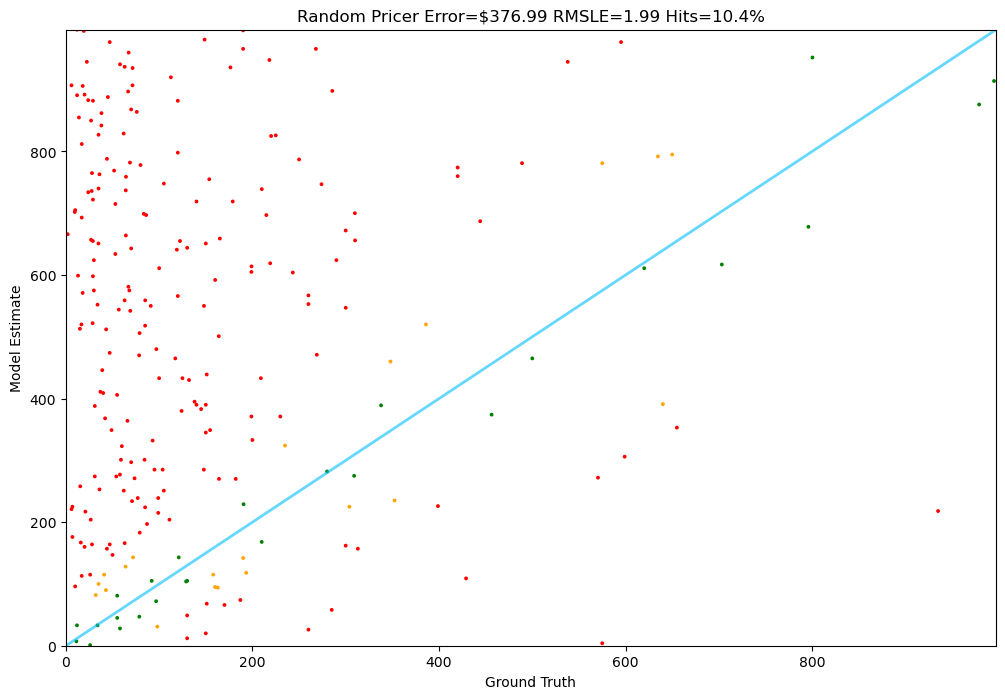

In [16]:
# Set the random seed

random.seed(42)

# Run our TestRunner
Tester.test(random_pricer)

In [17]:
# That was fun!
# We can do better - here's another rather trivial model

training_prices = [item.price for item in train]
training_average = sum(training_prices) / len(training_prices)

def constant_pricer(item):
    return training_average

1: Guess: $159.75 Truth: $28.95 Error: $130.80 SLE: 2.82 Item: Arch Memory AM-D3NS1866L-4G 4GB 204-Pin ...
2: Guess: $159.75 Truth: $25.99 Error: $133.76 SLE: 3.18 Item: Dreamus LIGHTSUM - Into The Light 1st Mi...
3: Guess: $159.75 Truth: $260.00 Error: $100.25 SLE: 0.23 Item: Belden 1613AP, Plenum Rated RG6 Coaxial ...
4: Guess: $159.75 Truth: $419.99 Error: $260.24 SLE: 0.93 Item: Garmin Enduro, Ultraperformance Multispo...
5: Guess: $159.75 Truth: $279.99 Error: $120.24 SLE: 0.31 Item: JOYLDIAS Kids Ride On Police Car, 12V Ba...
6: Guess: $159.75 Truth: $62.02 Error: $97.73 SLE: 0.88 Item: Middle Atlantic Products The Brush Gromm...
7: Guess: $159.75 Truth: $190.49 Error: $30.74 SLE: 0.03 Item: Canon EF-M 22mm f2 STM Compact System Fi...
8: Guess: $159.75 Truth: $120.99 Error: $38.76 SLE: 0.08 Item: VideoSecu 700TVL Day Night IR CCTV Wide ...
9: Guess: $159.75 Truth: $153.67 Error: $6.08 SLE: 0.00 Item: Pioneer Pioneer SE-M521 Headphone Sealed...
10: Guess: $159.75 Truth: $91.99 Err

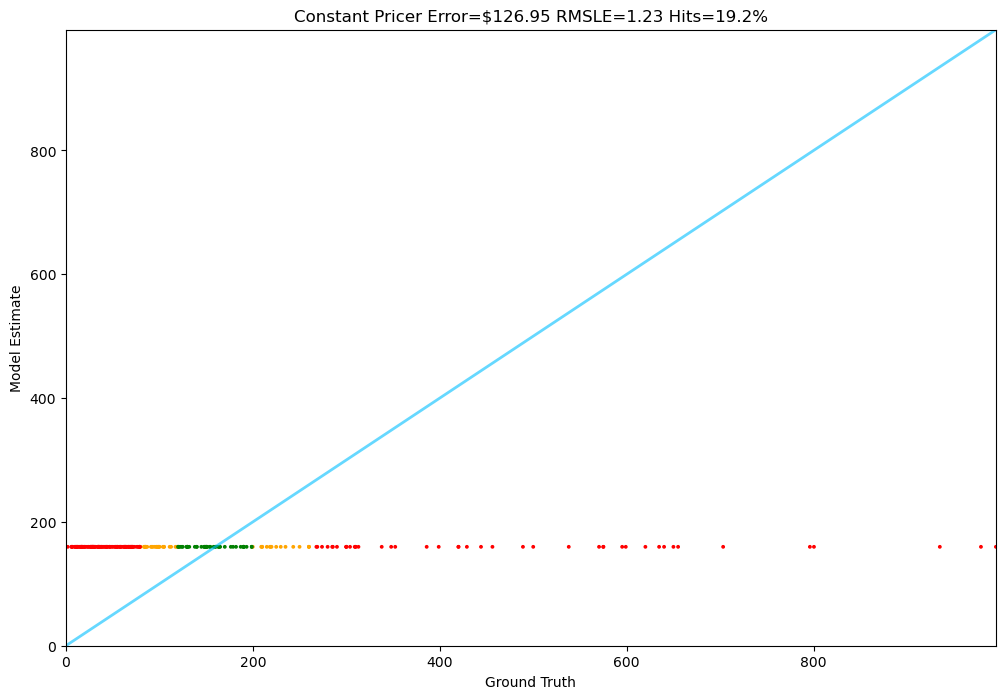

In [18]:
# Run our constant predictor
Tester.test(constant_pricer)


In [19]:
train[0].details

'{"Product Dimensions": "7 x 3.5 x 0.2 inches", "Item Weight": "0.32 ounces", "Item model number": "6521", "Manufacturer recommended age": "6 - 15 years", "Best Sellers Rank": {"Toys & Games": 813253, "Novelty Toys & Amusements": 48084}, "Is Discontinued By Manufacturer": "No", "Department": "womens", "Manufacturer": "Getting Fit"}'

In [20]:
# Create a new "features" field on items, and populate it with json parsed from the details dict

for item in train:
    item.features = json.loads(item.details)
for item in test:
    item.features = json.loads(item.details)

# Look at one

In [21]:
train[0].features.keys()

dict_keys(['Product Dimensions', 'Item Weight', 'Item model number', 'Manufacturer recommended age', 'Best Sellers Rank', 'Is Discontinued By Manufacturer', 'Department', 'Manufacturer'])

In [22]:
# Look at 20 most common features in training set

feature_count = Counter()
for item in train:
    for f in item.features.keys():
        feature_count[f]+=1

feature_count.most_common(40)

[('Item Weight', 171649),
 ('Manufacturer', 163342),
 ('Best Sellers Rank', 159081),
 ('Date First Available', 137558),
 ('Item model number', 137308),
 ('Brand', 134694),
 ('Product Dimensions', 130174),
 ('Is Discontinued By Manufacturer', 84158),
 ('Color', 68501),
 ('Manufacturer recommended age', 47399),
 ('Country of Origin', 46105),
 ('Special Feature', 40085),
 ('Package Dimensions', 38782),
 ('Compatible Devices', 33769),
 ('Connectivity Technology', 30820),
 ('Material', 28857),
 ('Model Name', 28268),
 ('Batteries', 26972),
 ('Item Dimensions  LxWxH', 26587),
 ('Item Dimensions LxWxH', 25917),
 ('Screen Size', 20779),
 ('Operating System', 17822),
 ('Series', 17664),
 ('Included Components', 17495),
 ('Standing screen display size', 16666),
 ('RAM', 16608),
 ('Release date', 15786),
 ('Hard Drive', 15698),
 ('Computer Memory Type', 15145),
 ('Voltage', 15067),
 ('Hardware Platform', 14557),
 ('Power Source', 14267),
 ('Processor Brand', 14199),
 ('Number of Processors', 1416

In [23]:
# Now some janky code to pluck out the Item Weight
# Don't worry too much about this: spoiler alert, it's not going to be much use in training!

def get_weight(item):
    weight_str = item.features.get('Item Weight')
    if weight_str:
        parts = weight_str.split(' ')
        amount = float(parts[0])
        unit = parts[1].lower()
        if unit=="pounds":
            return amount
        elif unit=="ounces":
            return amount / 16
        elif unit=="grams":
            return amount / 453.592
        elif unit=="milligrams":
            return amount / 453592
        elif unit=="kilograms":
            return amount / 0.453592
        elif unit=="hundredths" and parts[2].lower()=="pounds":
            return amount / 100
        else:
            print(weight_str)
    return None

In [24]:
weights = [get_weight(t) for t in train]
weights = [w for w in weights if w]

In [25]:
average_weight = sum(weights)/len(weights)
average_weight

4.665178876498072

In [26]:
def get_weight_with_default(item):
    weight = get_weight(item)
    return weight or average_weight

In [27]:
def get_rank(item):
    rank_dict = item.features.get("Best Sellers Rank")
    if rank_dict:
        ranks = rank_dict.values()
        return sum(ranks)/len(ranks)
    return None

In [28]:
ranks = [get_rank(t) for t in train]
ranks = [r for r in ranks if r]
average_rank = sum(ranks)/len(ranks)
average_rank

115464.91476557998

In [29]:
def get_rank_with_default(item):
    rank = get_rank(item)
    return rank or average_rank

In [30]:
def get_text_length(item):
    return len(item.test_prompt())

In [31]:
# investigate the brands

brands = Counter()
for t in train:
    brand = t.features.get("Brand")
    if brand:
        brands[brand]+=1

# Look at most common 40 brands

brands.most_common(40)

[('HP', 5093),
 ('Dell', 3657),
 ('Lenovo', 2711),
 ('Sony', 1600),
 ('ASUS', 1598),
 ('SAMSUNG', 1513),
 ('Funko', 1029),
 ('Canon', 961),
 ('Magic The Gathering', 870),
 ('Intel', 843),
 ('Apple', 801),
 ('Garmin', 633),
 ('Nikon', 616),
 ('GODOX', 579),
 ('Generic', 541),
 ('MSI', 509),
 ('Pyle', 499),
 ('Microsoft', 492),
 ('Panasonic', 485),
 ('Logitech', 467),
 ('A-Tech', 458),
 ('Yu-Gi-Oh!', 450),
 ('LG', 447),
 ('Acer', 418),
 ('Western Digital', 405),
 ('KICKER', 395),
 ('Seagate', 391),
 ('Pokemon', 383),
 ('AmScope', 369),
 ('Fujifilm', 363),
 ('Harmony Audio', 347),
 ('Gigabyte', 342),
 ('NETGEAR', 342),
 ('Plantronics', 329),
 ('Olympus', 318),
 ('Corsair', 312),
 ('JBL', 307),
 ('acer', 292),
 ('Cisco', 286),
 ('Kastar', 282)]

In [32]:
import re

# investigate the dimensions

dimensions = Counter()
for t in train:
    dimension = t.features.get("Product Dimensions")
    if dimension:
        dimensions[dimension]+=1

# Look at most common 40 dimensions

dimensions.most_common(40)

def parse_and_multiply_dimensions(item):
    dim_str = item.features.get("Product Dimensions", "")
    # Find all numbers (including decimals)
    numbers = re.findall(r"[\d.]+", dim_str)
    # Take the first 3 numbers and convert to float
    dims = [float(n) for n in numbers[:3]]
    if len(dims) == 3:
        return dims[0] * dims[1] * dims[2]
    else:
        return 0

In [33]:
TOP_ELECTRONICS_BRANDS = ["hp", "dell", "lenovo", "samsung", "asus", "sony", "canon", "apple", "intel"]
def is_top_electronics_brand(item):
    brand = item.features.get("Brand")
    return brand and brand.lower() in TOP_ELECTRONICS_BRANDS

In [34]:
def get_features(item):
    return {
        "weight": get_weight_with_default(item),
        "rank": get_rank_with_default(item),
        "text_length": get_text_length(item),
        "is_top_electronics_brand": 1 if is_top_electronics_brand(item) else 0,
        # "volume": parse_and_multiply_dimensions(item),
    }

In [35]:
# Look at features in a training item
get_features(train[0])

{'weight': 0.02,
 'rank': 430668.5,
 'text_length': 729,
 'is_top_electronics_brand': 0}

In [36]:
# A utility function to convert our features into a pandas dataframe

def list_to_dataframe(items):
    features = [get_features(item) for item in items]
    df = pd.DataFrame(features)
    df['price'] = [item.price for item in items]
    return df

train_df = list_to_dataframe(train)
test_df = list_to_dataframe(test[:250])

In [37]:
# Traditional Linear Regression!

np.random.seed(42)

# Separate features and target
feature_columns = ['weight', 'rank', 'text_length', 'is_top_electronics_brand']  # 'volume']

X_train = train_df[feature_columns]
y_train = train_df['price']
X_test = test_df[feature_columns]
y_test = test_df['price']

# Train a Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

for feature, coef in zip(feature_columns, model.coef_):
    print(f"{feature}: {coef}")
print(f"Intercept: {model.intercept_}")

# Predict the test set and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared Score: {r2}")

weight: 0.8765284483307049
rank: -4.777425012034164e-05
text_length: -0.1059898735787589
is_top_electronics_brand: 215.0980561129644
Intercept: 216.84756385882213
Mean Squared Error: 28605.197970167963
R-squared Score: 0.13446038413918338


In [38]:
# Function to predict price for a new item

def linear_regression_pricer(item):
    features = get_features(item)
    features_df = pd.DataFrame([features])
    return model.predict(features_df)[0]

1: Guess: $159.04 Truth: $28.95 Error: $130.09 SLE: 2.81 Item: Arch Memory AM-D3NS1866L-4G 4GB 204-Pin ...
2: Guess: $142.46 Truth: $25.99 Error: $116.47 SLE: 2.79 Item: Dreamus LIGHTSUM - Into The Light 1st Mi...
3: Guess: $157.58 Truth: $260.00 Error: $102.42 SLE: 0.25 Item: Belden 1613AP, Plenum Rated RG6 Coaxial ...
4: Guess: $127.92 Truth: $419.99 Error: $292.07 SLE: 1.40 Item: Garmin Enduro, Ultraperformance Multispo...
5: Guess: $144.62 Truth: $279.99 Error: $135.37 SLE: 0.43 Item: JOYLDIAS Kids Ride On Police Car, 12V Ba...
6: Guess: $146.94 Truth: $62.02 Error: $84.92 SLE: 0.73 Item: Middle Atlantic Products The Brush Gromm...
7: Guess: $339.81 Truth: $190.49 Error: $149.32 SLE: 0.33 Item: Canon EF-M 22mm f2 STM Compact System Fi...
8: Guess: $135.08 Truth: $120.99 Error: $14.09 SLE: 0.01 Item: VideoSecu 700TVL Day Night IR CCTV Wide ...
9: Guess: $129.51 Truth: $153.67 Error: $24.16 SLE: 0.03 Item: Pioneer Pioneer SE-M521 Headphone Sealed...
10: Guess: $152.80 Truth: $91.99 E

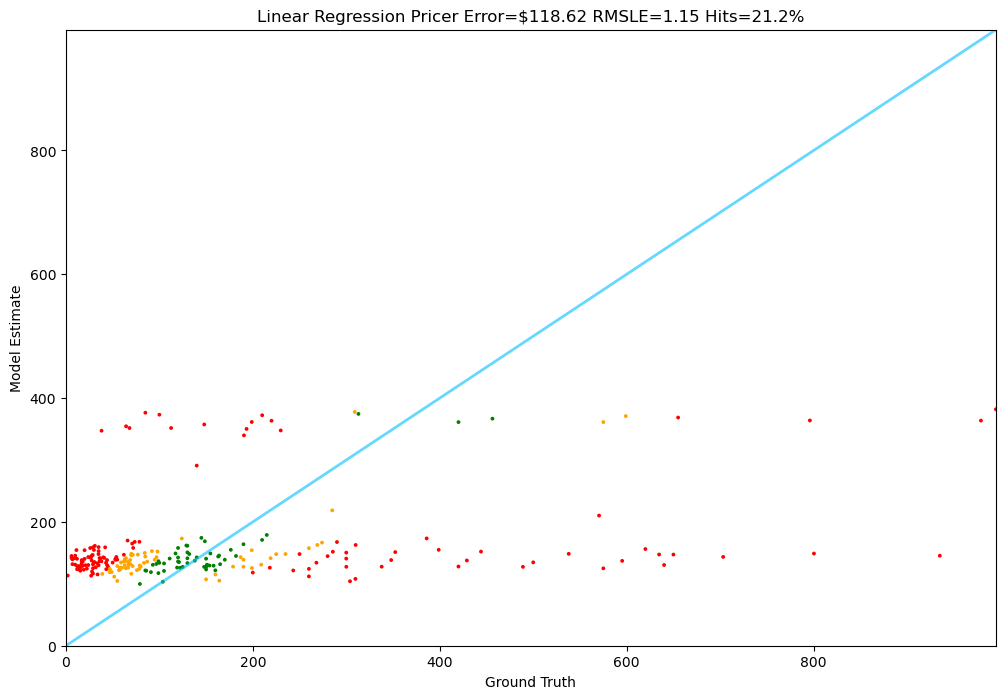

In [39]:
# test it

Tester.test(linear_regression_pricer)

In [40]:
# For the next few models, we prepare our documents and prices
# Note that we use the test prompt for the documents, otherwise we'll reveal the answer!!

prices = np.array([float(item.price) for item in train])
documents = [item.test_prompt() for item in train]

In [41]:
# Use the CountVectorizer for a Bag of Words model

np.random.seed(42)
vectorizer = CountVectorizer(max_features=1000, stop_words='english')
X = vectorizer.fit_transform(documents)
regressor = LinearRegression()
regressor.fit(X, prices)

LinearRegression()

In [42]:
def bow_lr_pricer(item):
    x = vectorizer.transform([item.test_prompt()])
    return max(regressor.predict(x)[0], 0)

1: Guess: $101.36 Truth: $28.95 Error: $72.41 SLE: 1.51 Item: Arch Memory AM-D3NS1866L-4G 4GB 204-Pin ...
2: Guess: $79.60 Truth: $25.99 Error: $53.61 SLE: 1.20 Item: Dreamus LIGHTSUM - Into The Light 1st Mi...
3: Guess: $158.04 Truth: $260.00 Error: $101.96 SLE: 0.25 Item: Belden 1613AP, Plenum Rated RG6 Coaxial ...
4: Guess: $224.22 Truth: $419.99 Error: $195.77 SLE: 0.39 Item: Garmin Enduro, Ultraperformance Multispo...
5: Guess: $189.17 Truth: $279.99 Error: $90.82 SLE: 0.15 Item: JOYLDIAS Kids Ride On Police Car, 12V Ba...
6: Guess: $119.90 Truth: $62.02 Error: $57.88 SLE: 0.42 Item: Middle Atlantic Products The Brush Gromm...
7: Guess: $279.96 Truth: $190.49 Error: $89.47 SLE: 0.15 Item: Canon EF-M 22mm f2 STM Compact System Fi...
8: Guess: $201.52 Truth: $120.99 Error: $80.53 SLE: 0.26 Item: VideoSecu 700TVL Day Night IR CCTV Wide ...
9: Guess: $185.48 Truth: $153.67 Error: $31.81 SLE: 0.03 Item: Pioneer Pioneer SE-M521 Headphone Sealed...
10: Guess: $90.90 Truth: $91.99 Error: 

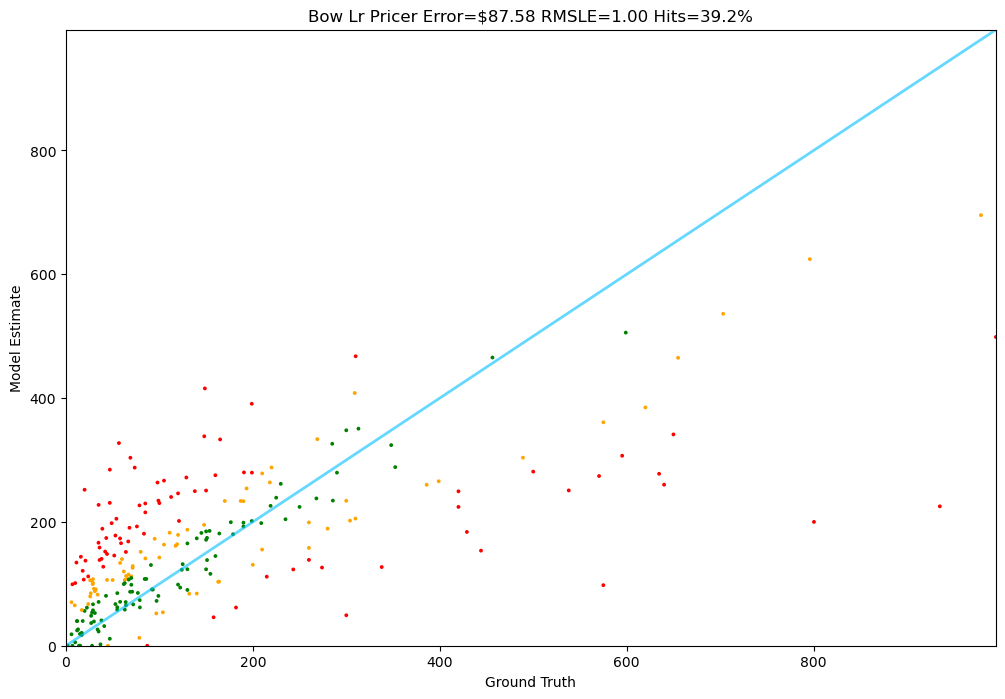

In [43]:
# test it

Tester.test(bow_lr_pricer)

In [44]:
# The amazing word2vec model, implemented in gensim NLP library

np.random.seed(42)

# Preprocess the documents
processed_docs = [simple_preprocess(doc) for doc in documents]

# Train Word2Vec model
w2v_model = Word2Vec(sentences=processed_docs, vector_size=400, window=5, min_count=1, workers=8)

In [45]:
# This step of averaging vectors across the document is a weakness in our approach

def document_vector(doc):
    doc_words = simple_preprocess(doc)
    word_vectors = [w2v_model.wv[word] for word in doc_words if word in w2v_model.wv]
    return np.mean(word_vectors, axis=0) if word_vectors else np.zeros(w2v_model.vector_size)

# Create feature matrix
X_w2v = np.array([document_vector(doc) for doc in documents])

In [46]:
# Run Linear Regression on word2vec

word2vec_lr_regressor = LinearRegression()
word2vec_lr_regressor.fit(X_w2v, prices)

LinearRegression()

In [47]:
def word2vec_lr_pricer(item):
    doc = item.test_prompt()
    doc_vector = document_vector(doc)
    return max(0, word2vec_lr_regressor.predict([doc_vector])[0])

1: Guess: $144.48 Truth: $28.95 Error: $115.53 SLE: 2.50 Item: Arch Memory AM-D3NS1866L-4G 4GB 204-Pin ...
2: Guess: $47.64 Truth: $25.99 Error: $21.65 SLE: 0.35 Item: Dreamus LIGHTSUM - Into The Light 1st Mi...
3: Guess: $213.36 Truth: $260.00 Error: $46.64 SLE: 0.04 Item: Belden 1613AP, Plenum Rated RG6 Coaxial ...
4: Guess: $247.08 Truth: $419.99 Error: $172.91 SLE: 0.28 Item: Garmin Enduro, Ultraperformance Multispo...
5: Guess: $163.32 Truth: $279.99 Error: $116.67 SLE: 0.29 Item: JOYLDIAS Kids Ride On Police Car, 12V Ba...
6: Guess: $157.69 Truth: $62.02 Error: $95.67 SLE: 0.85 Item: Middle Atlantic Products The Brush Gromm...
7: Guess: $293.48 Truth: $190.49 Error: $102.99 SLE: 0.19 Item: Canon EF-M 22mm f2 STM Compact System Fi...
8: Guess: $233.55 Truth: $120.99 Error: $112.56 SLE: 0.43 Item: VideoSecu 700TVL Day Night IR CCTV Wide ...
9: Guess: $204.56 Truth: $153.67 Error: $50.89 SLE: 0.08 Item: Pioneer Pioneer SE-M521 Headphone Sealed...
10: Guess: $125.68 Truth: $91.99 Err

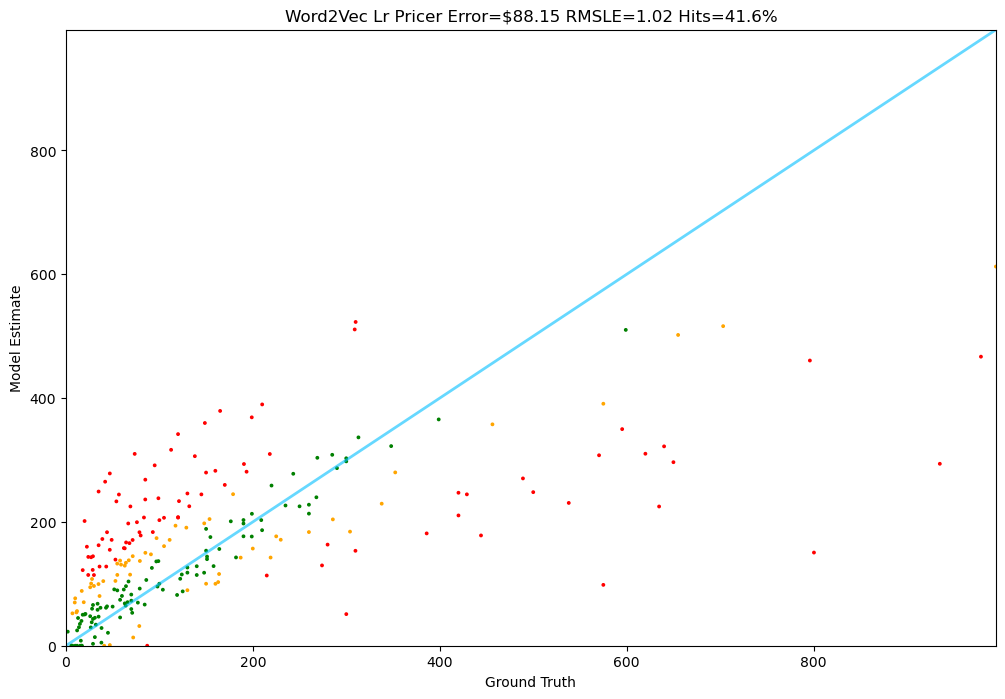

In [48]:
Tester.test(word2vec_lr_pricer)

In [49]:
# Support Vector Machines

np.random.seed(42)
svr_regressor = LinearSVR()

svr_regressor.fit(X_w2v, prices)

LinearSVR()

In [50]:
def svr_pricer(item):
    np.random.seed(42)
    doc = item.test_prompt()
    doc_vector = document_vector(doc)
    return max(float(svr_regressor.predict([doc_vector])[0]),0)

1: Guess: $118.57 Truth: $28.95 Error: $89.62 SLE: 1.92 Item: Arch Memory AM-D3NS1866L-4G 4GB 204-Pin ...
2: Guess: $49.72 Truth: $25.99 Error: $23.73 SLE: 0.40 Item: Dreamus LIGHTSUM - Into The Light 1st Mi...
3: Guess: $148.73 Truth: $260.00 Error: $111.27 SLE: 0.31 Item: Belden 1613AP, Plenum Rated RG6 Coaxial ...
4: Guess: $166.70 Truth: $419.99 Error: $253.29 SLE: 0.85 Item: Garmin Enduro, Ultraperformance Multispo...
5: Guess: $124.06 Truth: $279.99 Error: $155.93 SLE: 0.66 Item: JOYLDIAS Kids Ride On Police Car, 12V Ba...
6: Guess: $74.77 Truth: $62.02 Error: $12.75 SLE: 0.03 Item: Middle Atlantic Products The Brush Gromm...
7: Guess: $208.86 Truth: $190.49 Error: $18.37 SLE: 0.01 Item: Canon EF-M 22mm f2 STM Compact System Fi...
8: Guess: $167.19 Truth: $120.99 Error: $46.20 SLE: 0.10 Item: VideoSecu 700TVL Day Night IR CCTV Wide ...
9: Guess: $158.90 Truth: $153.67 Error: $5.23 SLE: 0.00 Item: Pioneer Pioneer SE-M521 Headphone Sealed...
10: Guess: $90.80 Truth: $91.99 Error: $

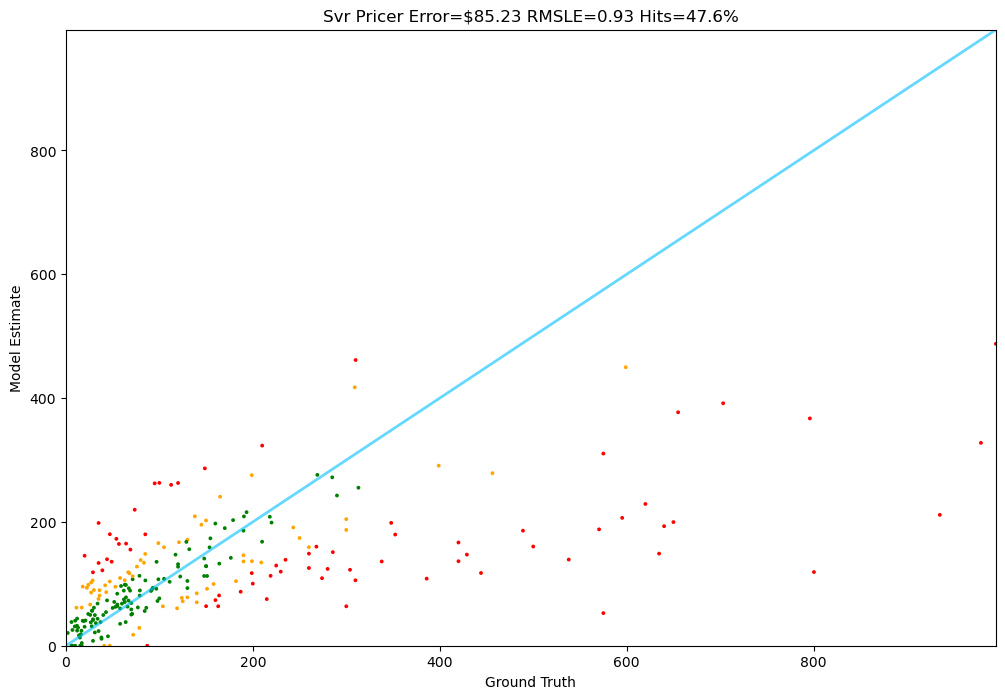

In [51]:
Tester.test(svr_pricer)

In [53]:
# And the powerful Random Forest regression

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=8)
rf_model.fit(X_w2v, prices)

RandomForestRegressor(n_jobs=8, random_state=42)

In [54]:
def random_forest_pricer(item):
    doc = item.test_prompt()
    doc_vector = document_vector(doc)
    return max(0, rf_model.predict([doc_vector])[0])

1: Guess: $80.96 Truth: $28.95 Error: $52.01 SLE: 1.01 Item: Arch Memory AM-D3NS1866L-4G 4GB 204-Pin ...
2: Guess: $94.09 Truth: $25.99 Error: $68.10 SLE: 1.59 Item: Dreamus LIGHTSUM - Into The Light 1st Mi...
3: Guess: $117.49 Truth: $260.00 Error: $142.51 SLE: 0.62 Item: Belden 1613AP, Plenum Rated RG6 Coaxial ...
4: Guess: $233.78 Truth: $419.99 Error: $186.21 SLE: 0.34 Item: Garmin Enduro, Ultraperformance Multispo...
5: Guess: $248.99 Truth: $279.99 Error: $31.00 SLE: 0.01 Item: JOYLDIAS Kids Ride On Police Car, 12V Ba...
6: Guess: $139.44 Truth: $62.02 Error: $77.42 SLE: 0.64 Item: Middle Atlantic Products The Brush Gromm...
7: Guess: $339.68 Truth: $190.49 Error: $149.19 SLE: 0.33 Item: Canon EF-M 22mm f2 STM Compact System Fi...
8: Guess: $142.58 Truth: $120.99 Error: $21.59 SLE: 0.03 Item: VideoSecu 700TVL Day Night IR CCTV Wide ...
9: Guess: $167.23 Truth: $153.67 Error: $13.56 SLE: 0.01 Item: Pioneer Pioneer SE-M521 Headphone Sealed...
10: Guess: $112.92 Truth: $91.99 Error:

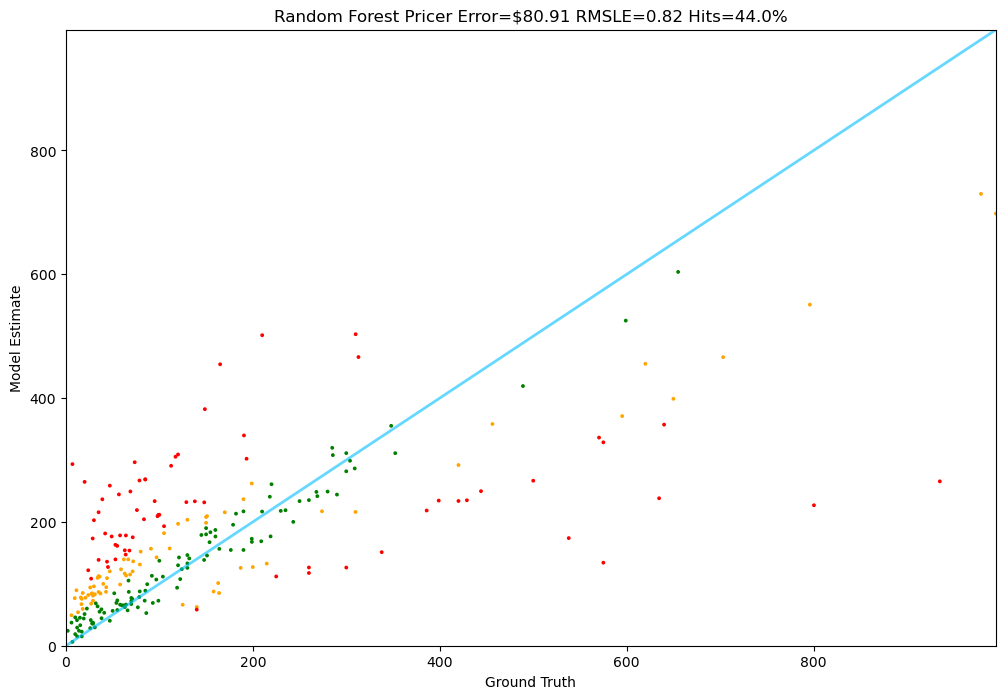

In [55]:
Tester.test(random_forest_pricer)